In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

CSV_PATH = "/Users/edwinzheng/Seed2s-Reveal-Unified-Methodology/Prospective Team/Data/Processed/south_america_cleaned.csv"
df = pd.read_csv(CSV_PATH)

annual = df.groupby(["Year", "Country", "Commodity Name", "HS Code", "Category Type"])[["Nominal Value", "Real Value"]].sum().reset_index()

print(f"Rows loaded: {len(df)}")
print(f"Years: {annual['Year'].min()} - {annual['Year'].max()}")
print(f"Countries ({annual['Country'].nunique()}): {sorted(annual['Country'].unique())}")
annual.head()

Rows loaded: 6446
Years: 2010 - 2025
Countries (13): ['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Ecuador', 'French Guiana', 'Guyana', 'Paraguay', 'Peru', 'Suriname', 'Uruguay', 'Venezuela']


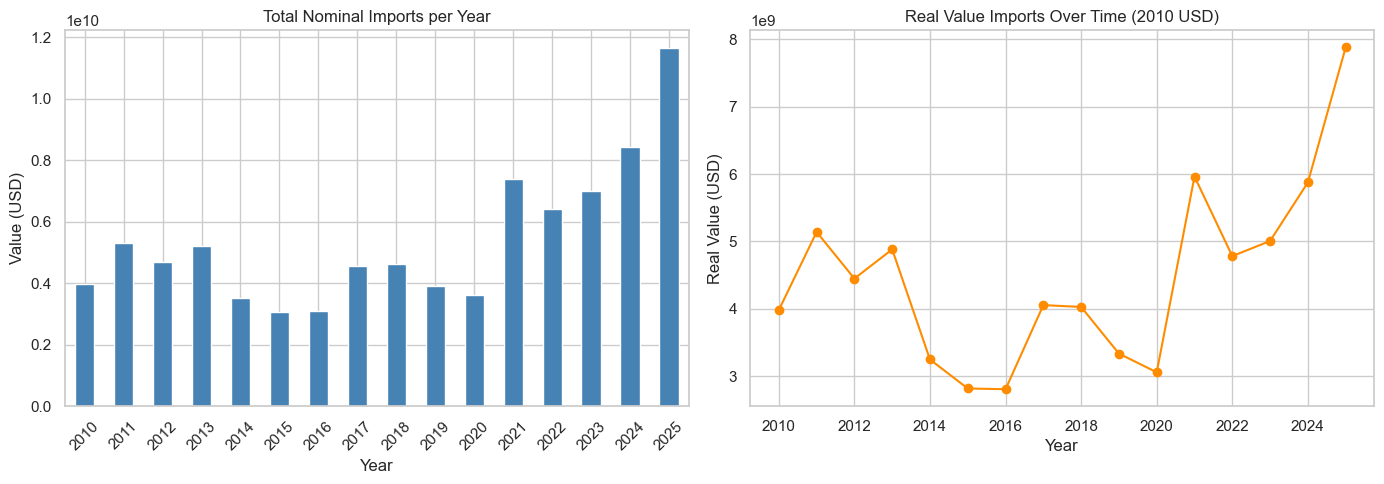

In [2]:
yearly = annual.groupby("Year")[["Nominal Value", "Real Value"]].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
yearly["Nominal Value"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Nominal Imports per Year")
axes[0].set_ylabel("Value (USD)")
axes[0].tick_params(axis='x', rotation=45)

yearly["Real Value"].plot(kind="line", ax=axes[1], marker="o", color="darkorange")
axes[1].set_title("Real Value Imports Over Time (2010 USD)")
axes[1].set_ylabel("Real Value (USD)")
axes[1].set_xlabel("Year")
plt.tight_layout()
plt.show()

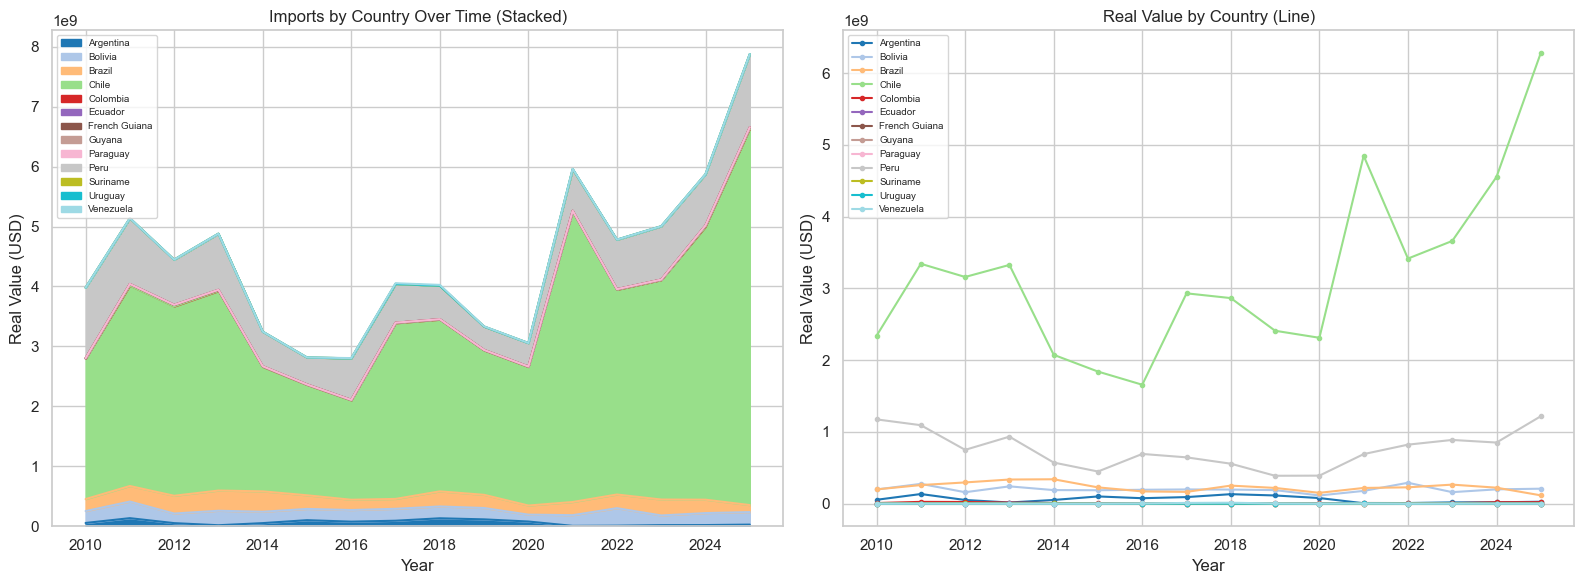

In [3]:
country_year = annual.groupby(["Year", "Country"])["Real Value"].sum().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
country_year.plot(kind="area", stacked=True, ax=axes[0], colormap="tab20")
axes[0].set_title("Imports by Country Over Time (Stacked)")
axes[0].set_ylabel("Real Value (USD)")
axes[0].legend(loc="upper left", fontsize=7)

country_year.plot(kind="line", ax=axes[1], marker="o", markersize=3, colormap="tab20")
axes[1].set_title("Real Value by Country (Line)")
axes[1].set_ylabel("Real Value (USD)")
axes[1].legend(loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()


Country share (%):
Country
Chile            71.56
Peru             17.01
Brazil            5.15
Bolivia           4.47
Argentina         1.39
Colombia          0.27
Venezuela         0.05
Suriname          0.04
Ecuador           0.04
Uruguay           0.01
Guyana            0.01
Paraguay          0.00
French Guiana     0.00


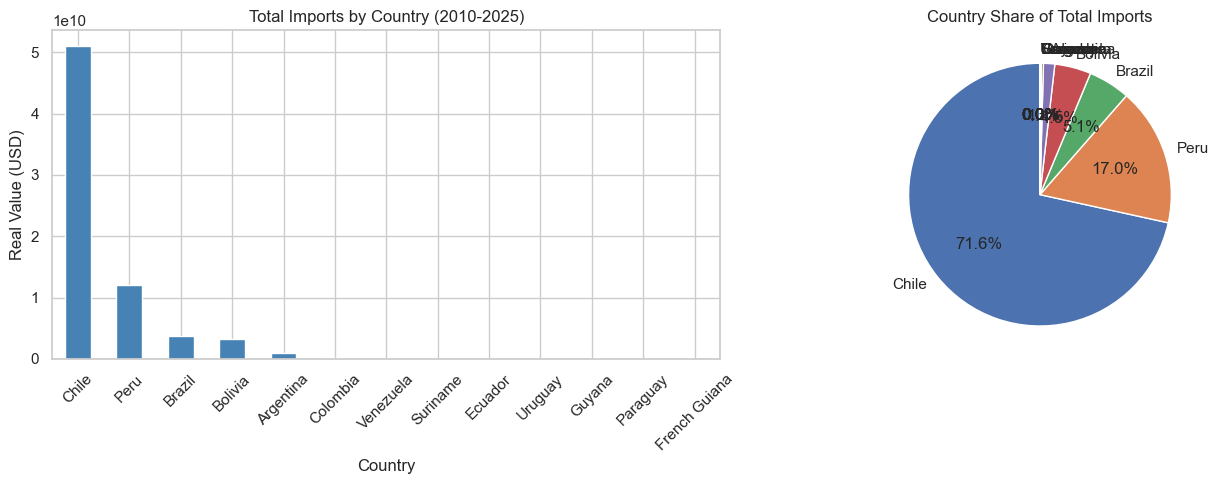

In [4]:
country_totals = annual.groupby("Country")["Real Value"].sum().sort_values(ascending=False)
total_real = country_totals.sum()
country_pct = (country_totals / total_real * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_totals.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Imports by Country (2010-2025)")
axes[0].set_ylabel("Real Value (USD)")
axes[0].tick_params(axis='x', rotation=45)

country_pct.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=90)
axes[1].set_title("Country Share of Total Imports")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

print("\nCountry share (%):")
print(country_pct.to_string())

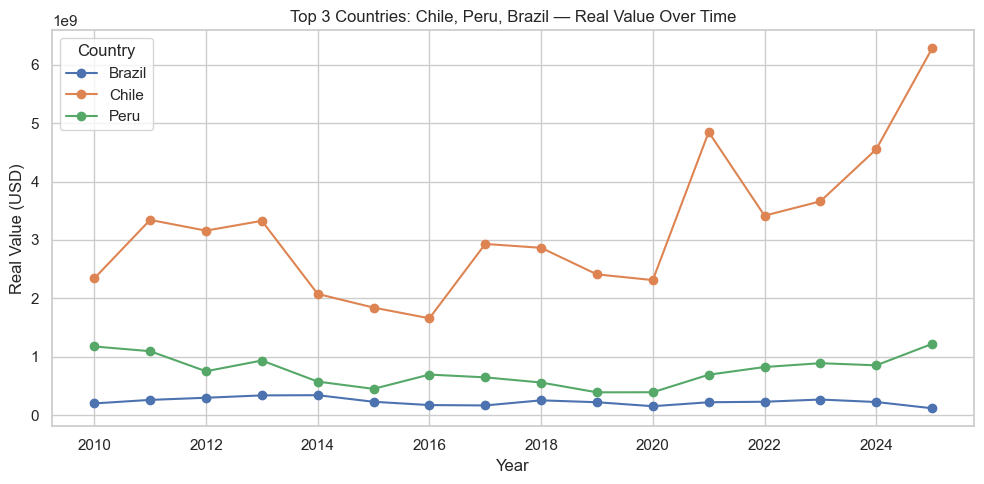

In [5]:
top3 = country_totals.head(3).index.tolist()
top3_ts = annual[annual["Country"].isin(top3)].groupby(["Year", "Country"])["Real Value"].sum().unstack()

top3_ts.plot(kind="line", figsize=(10, 5), marker="o")
plt.title(f"Top 3 Countries: {', '.join(top3)} — Real Value Over Time")
plt.ylabel("Real Value (USD)")
plt.xlabel("Year")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

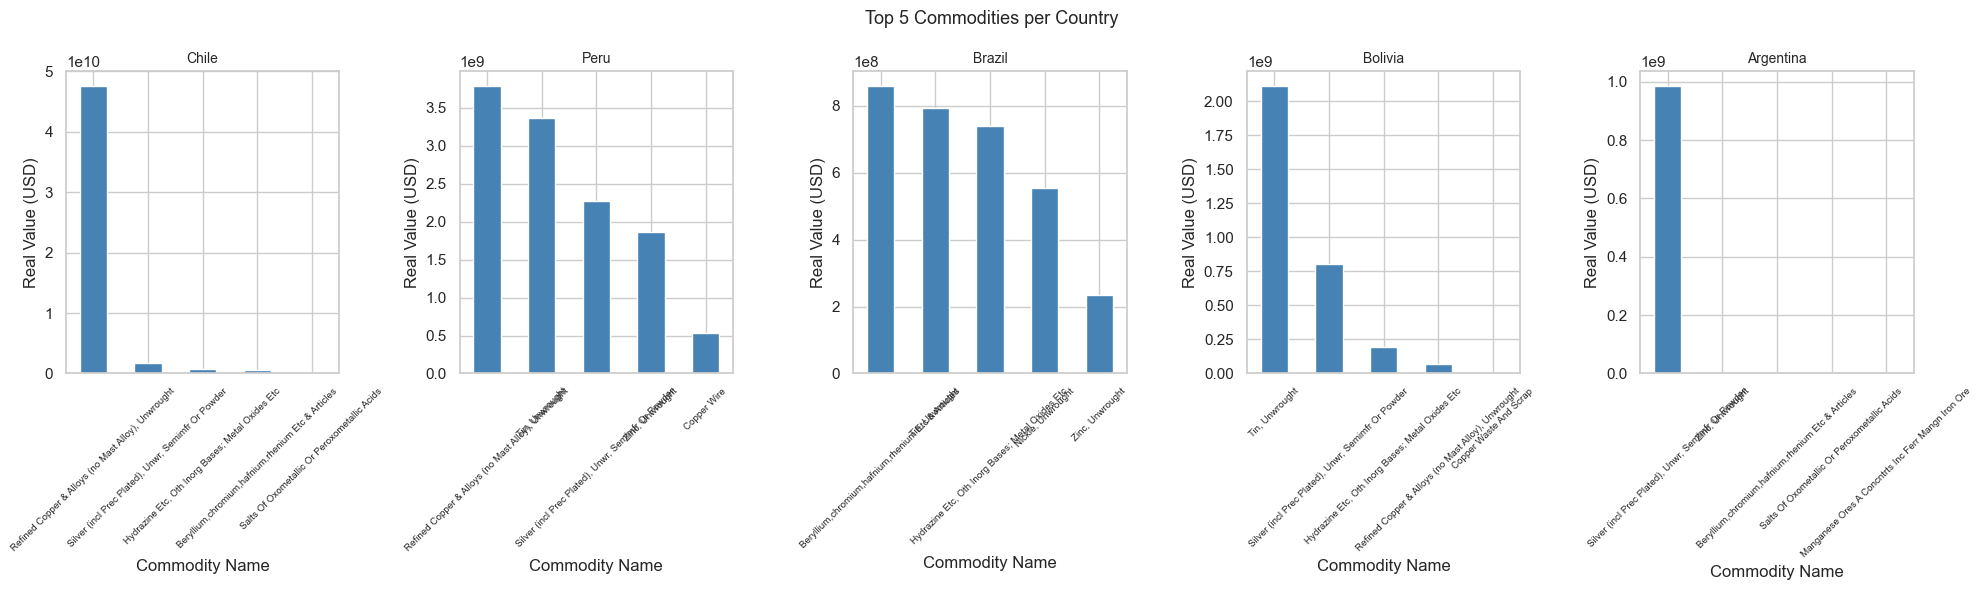

In [6]:
top5_countries = country_totals.head(5).index.tolist()

fig, axes = plt.subplots(1, len(top5_countries), figsize=(20, 6), sharey=False)
for ax, country in zip(axes, top5_countries):
    subset = annual[annual["Country"] == country]
    top_comm = subset.groupby("Commodity Name")["Real Value"].sum().sort_values(ascending=False).head(5)
    top_comm.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(country, fontsize=10)
    ax.set_ylabel("Real Value (USD)")
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.suptitle("Top 5 Commodities per Country", fontsize=13)
plt.tight_layout()
plt.show()

Top 10 share (%):
Commodity Name
Refined Copper & Alloys (no Mast Alloy), Unwrought    72.37
Tin, Unwrought                                         8.84
Silver (incl Prec Plated), Unwr, Semimfr Or Powder     8.22
Zinc, Unwrought                                        2.94
Hydrazine Etc, Oth Inorg Bases; Metal Oxides Etc       2.34
Beryllium,chromium,hafnium,rhenium Etc & Articles      2.06
Copper Wire                                            0.94
Nickle, Unwrought                                      0.79
Salts Of Oxometallic Or Peroxometallic Acids           0.33
Copper Waste And Scrap                                 0.29


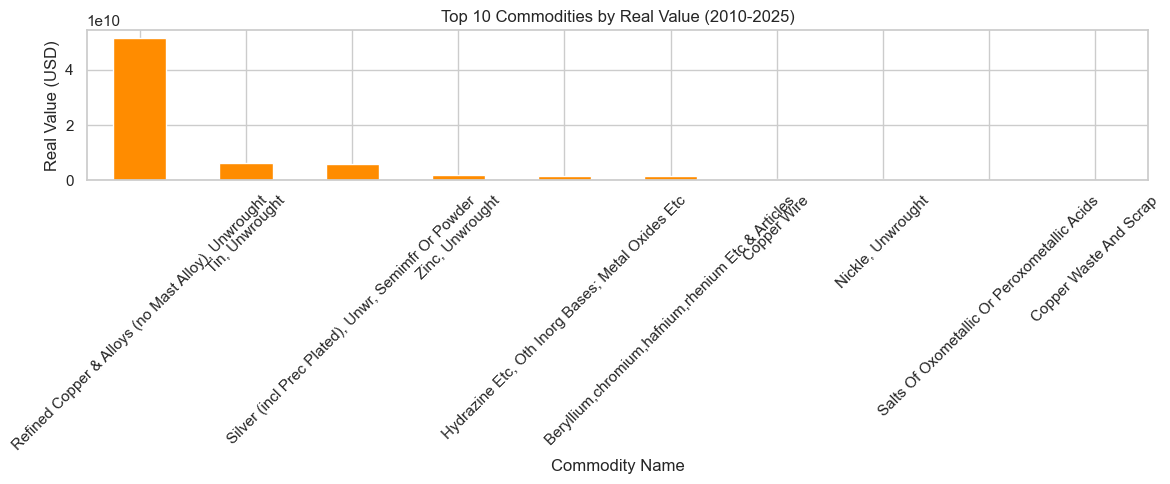

In [7]:
top10 = annual.groupby("Commodity Name")["Real Value"].sum().sort_values(ascending=False).head(10)

top10.plot(kind="bar", figsize=(12, 5), color="darkorange")
plt.title("Top 10 Commodities by Real Value (2010-2025)")
plt.ylabel("Real Value (USD)")
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Top 10 share (%):")
print((top10 / annual['Real Value'].sum() * 100).round(2).to_string())

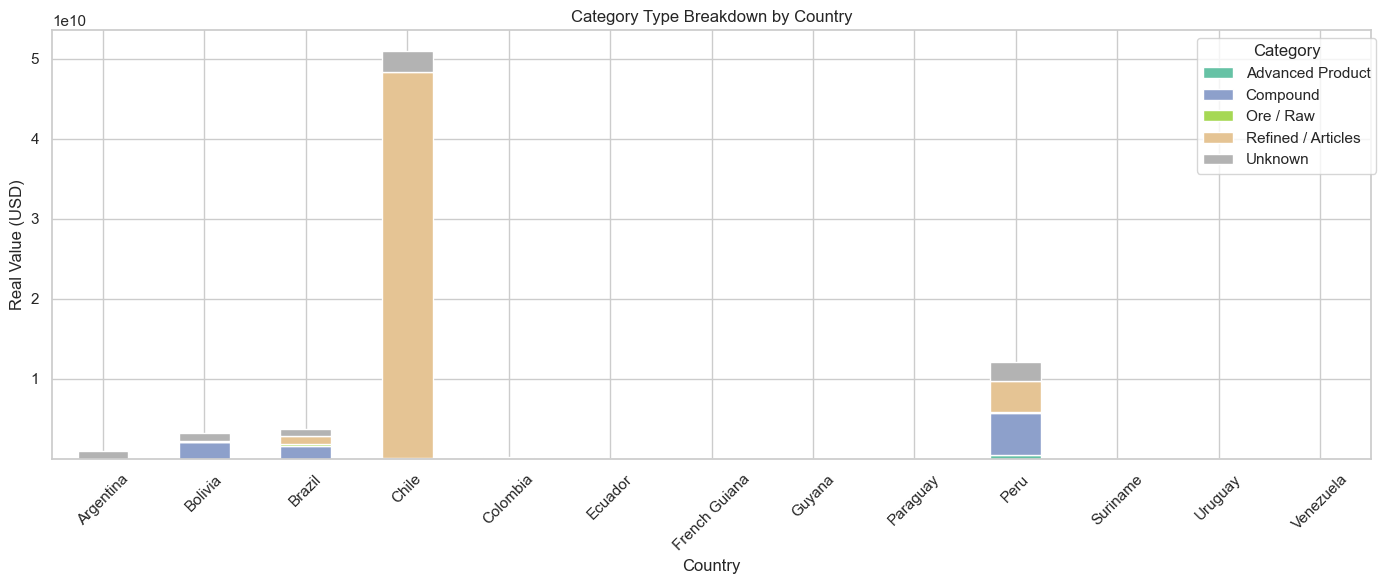

In [8]:
cat_country = annual.groupby(["Country", "Category Type"])["Real Value"].sum().unstack(fill_value=0)

cat_country.plot(kind="bar", stacked=True, figsize=(14, 6), colormap="Set2")
plt.title("Category Type Breakdown by Country")
plt.ylabel("Real Value (USD)")
plt.xlabel("Country")
plt.legend(title="Category", bbox_to_anchor=(1.01, 1))
plt.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

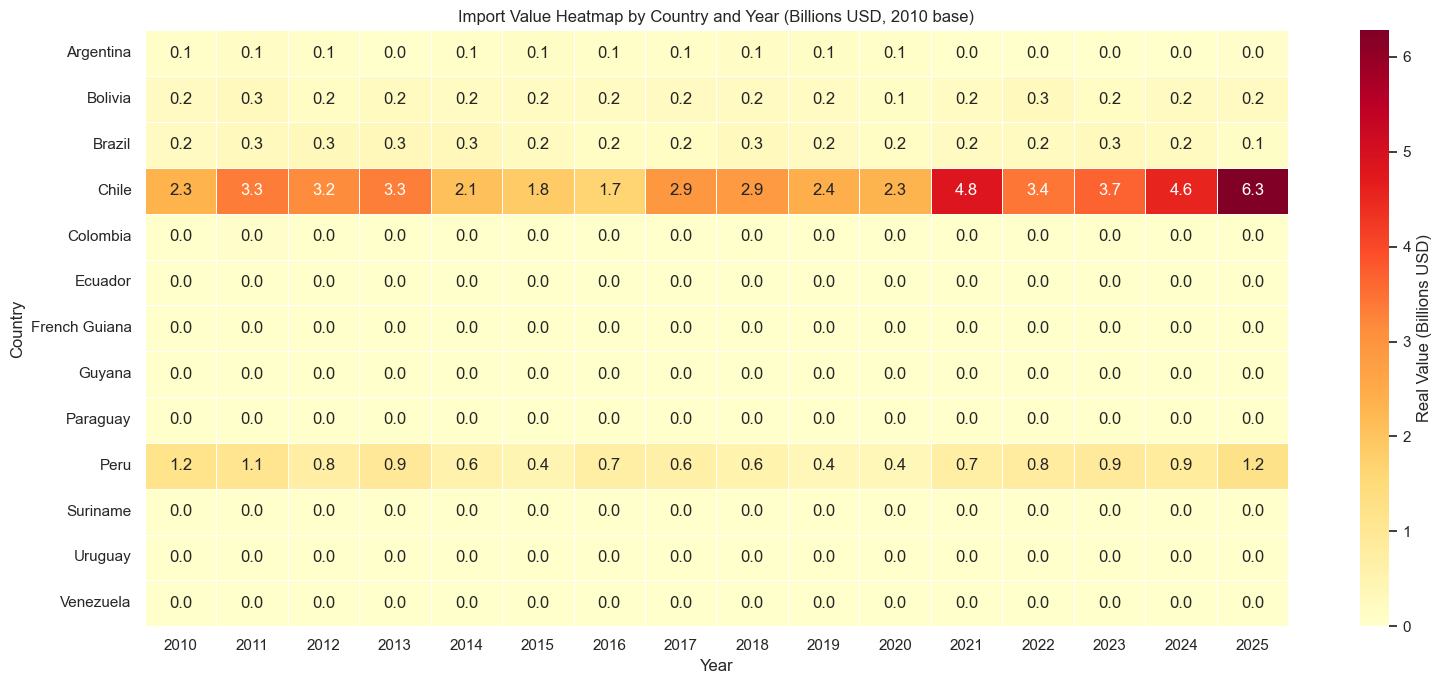

In [9]:
pivot = annual.groupby(["Country", "Year"])["Real Value"].sum().unstack(fill_value=0)

plt.figure(figsize=(16, 7))
sns.heatmap(pivot / 1e9, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Real Value (Billions USD)"})
plt.title("Import Value Heatmap by Country and Year (Billions USD, 2010 base)")
plt.xlabel("Year")
plt.ylabel("Country")
plt.tight_layout()
plt.show()